In [14]:
import pandas as pd
import numpy as np
import cv2
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten

# read the CSV file
df = pd.read_csv('20k_dataframe_2303.csv')

# extract the features and labels from the dataframe
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

# reshape the features to 2D arrays of size (height, width, channels)
X_images = []
for i in range(len(X)):
    x_reshaped = np.reshape(X[i], (5, 17, 1))
    # rescale the values to be between 0 and 255
    x_scaled = (255*(x_reshaped - np.min(x_reshaped))/(np.max(x_reshaped) - np.min(x_reshaped))).astype(np.uint8)
    # apply a Gaussian blur to reduce noise
    x_blurred = cv2.GaussianBlur(x_scaled, (3, 3), 0)
    X_images.append(x_blurred)

# convert the image data to a numpy array
X_images = np.array(X_images)

# create a CNN model
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(5, 17, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

# compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# train the model
model.fit(X_images, y, batch_size=32, epochs=10, validation_split=0.2)


ValueError: One of the dimensions in the output is <= 0 due to downsampling in conv2d_3. Consider increasing the input size. Received input shape [None, 1, 7, 32] which would produce output shape with a zero or negative value in a dimension.

In [23]:
import math

min(df.min(axis=1))

0

ValueError: too many values to unpack (expected 2)

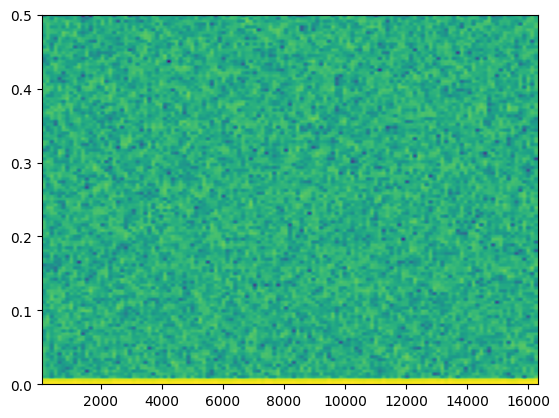

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Generate random ADC data
adc_data = np.random.rand(16384)

# Set spectrogram parameters
segment_length = 256
overlap = 128

# Compute spectrogram using Welch's method
f, t,  = plt.specgram(adc_data, NFFT=segment_length, Fs=1, noverlap=overlap)

# Plot spectrogram
plt.pcolormesh(t, f, 10*np.log10(Sxx), cmap='jet')
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (s)')
plt.colorbar()
plt.show()


In [5]:
import pandas as pd

df = pd.read_csv("../ipynb-files/Wall_test4_adc.txt", header=None, sep="\t")
print(df.shape)

(8, 16404)


In [12]:
df = df.iloc[:, 19:]

In [13]:
df.dropna(axis=1)

,19,20,21,22,23,24,25,26,27,28,...,16393,16394,16395,16396,16397,16398,16399,16400,16401,16402
0,-155,-161,-161,-162,-672,-725,-763,-791,-798,-785,...,-144,-142,-141,-140,-140,-138,-143,-147,-150,-154
1,-123,-125,-127,-122,-124,-448,-522,-595,-658,-717,...,-127,-126,-124,-123,-122,-126,-126,-123,-123,-122
2,-162,-156,-152,-145,-143,-143,-140,-1107,-1204,-1285,...,-188,-185,-182,-182,-180,-180,-174,-167,-169,-167
3,-147,-147,-151,-151,-155,-154,-153,-155,-156,-154,...,-160,-157,-157,-156,-156,-155,-151,-148,-141,-145
4,-164,-160,-163,-169,42,50,52,47,27,-8,...,-159,-163,-163,-163,-163,-163,-158,-161,-163,-164
5,-221,-220,-222,-226,-229,-103,-168,-238,-308,-381,...,-233,-236,-234,-231,-231,-233,-232,-232,-229,-224
6,-145,-141,-134,-137,-136,51,69,77,75,69,...,-144,-146,-145,-147,-146,-150,-151,-146,-144,-146
7,-145,-141,-134,-137,-136,51,69,77,75,69,...,-144,-146,-145,-147,-146,-150,-151,-146,-144,-146


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense



# Read CSV file into a Pandas dataframe
data = pd.read_csv("final_dataframe_complete_experiment.csv", header=None)

# Split features and target variable
X = data.iloc[:, 1:]
y = data.iloc[:, 0]

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=23)

# Load dataset
data = np.load('data.npy')
target = np.load('target.npy')

# Reshape data into 3D format
data = data.reshape(-1, 85, 1)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=42)

# Define CNN model
model = Sequential()
model.add(Conv1D(64, 3, activation='relu', input_shape=(85, 1)))
model.add(MaxPooling1D(2))
model.add(Conv1D(128, 3, activation='relu'))
model.add(MaxPooling1D(2))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train model
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))
